In [28]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [29]:
class BatsmenState(TypedDict):
    runs: int
    balls: int
    four: int
    six: int

    strike_rate: float
    balls_per_boundary: float
    boundary_percentage: float


In [30]:
def calculate_strike_rate(state: BatsmenState) -> BatsmenState:
    strike_rate = (state['runs'] / state['balls']) * 100 if state['balls'] > 0 else 0
    return {'strike_rate': round(strike_rate,2)}

def calculate_balls_per_boundary(state: BatsmenState) -> BatsmenState:
    total_boundaries = state['four'] + state['six']
    balls_per_boundary = (state['balls'] / total_boundaries) if total_boundaries > 0 else 0
    return {'balls_per_boundary': round(balls_per_boundary,2)}

def calculate_boundary_percentage(state: BatsmenState) -> BatsmenState:
    total_boundaries = state['four'] + state['six']
    boundary_percentage = (total_boundaries / state['balls']) * 100 if state['balls'] > 0 else 0
    return {'boundary_percentage': round(boundary_percentage,2)}

In [31]:
graph = StateGraph(BatsmenState)
graph.add_node("calculate_strike_rate", calculate_strike_rate)
graph.add_node("calculate_balls_per_boundary", calculate_balls_per_boundary)
graph.add_node("calculate_boundary_percentage", calculate_boundary_percentage)


graph.add_edge(START, "calculate_strike_rate")
graph.add_edge(START, "calculate_balls_per_boundary")
graph.add_edge(START, "calculate_boundary_percentage")

graph.add_edge("calculate_strike_rate", END)
graph.add_edge("calculate_balls_per_boundary", END)
graph.add_edge("calculate_boundary_percentage", END)

workflow = graph.compile()

In [32]:
query = {"runs": 120, "balls": 100, "four": 10, "six": 5}
output = workflow.invoke(query)
print(output)

{'runs': 120, 'balls': 100, 'four': 10, 'six': 5, 'strike_rate': 120.0, 'balls_per_boundary': 6.67, 'boundary_percentage': 15.0}


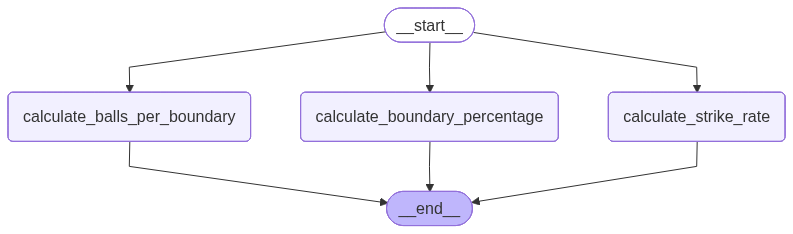

In [ ]:
from IPython.display import Image, Display
Image(workflow.get_graph().draw_mermaid_png())

now we are about to create a parallel LLM based workflow

                -----    clarity of thaught ----
essay input  --------    Depth of analysis  ------- evaluate ---- end
                -----    language           ----

In [42]:
from typing import Annotated, TypedDict
import operator

from langchain_ollama import ChatOllama
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END

In [43]:
class LLMState(TypedDict):
    topic: str
    outline: str
    essay: str

    clarity_feedback: str
    analysis_feedback: str
    language_feedback: str

    # This will cleanly accumulate all 3 scores during parallel execution
    individual_scores: Annotated[list[float], operator.add]
    overall_score: float

In [44]:
model = ChatOllama(model="mistral", temperature=0.0)

class EvaluationSchema(BaseModel):
    feedback: str = Field(description="Evaluation feedback for the essay.")
    score: float = Field(description="Evaluation score for the essay, between 0 and 10.", ge=0, le=10)

structured_output = model.with_structured_output(EvaluationSchema)

In [45]:
def create_essay(state: LLMState) -> dict:
    prompt = ChatPromptTemplate.from_template(
        "Write an essay based on the following outline: {outline}"
    )
    llm = ChatOllama(model="mistral", temperature=0.7)
    chain = prompt | llm | StrOutputParser()
    essay = chain.invoke({"outline": state['outline']})
    return {"essay": essay}

def evaluate_clarity(state: LLMState) -> dict:
    prompt = ChatPromptTemplate.from_template(
        "Evaluate the clarity of the following essay on a scale of 1 to 10 and provide detailed feedback: {essay}"
    )
    # Streamlined: Directly pipe the prompt into the structured output model
    evaluation_chain = prompt | structured_output
    output = evaluation_chain.invoke({"essay": state['essay']})
    return {"clarity_feedback": output.feedback, "individual_scores": [output.score]}

def evaluate_analysis(state: LLMState) -> dict:
    prompt = ChatPromptTemplate.from_template(
        "Evaluate the depth of analysis in the following essay on a scale of 1 to 10 and provide detailed feedback: {essay}"
    )
    evaluation_chain = prompt | structured_output
    output = evaluation_chain.invoke({"essay": state['essay']})
    return {"analysis_feedback": output.feedback, "individual_scores": [output.score]}

def evaluate_language(state: LLMState) -> dict:
    prompt = ChatPromptTemplate.from_template(
        "Evaluate the quality of language in the following essay on a scale of 1 to 10 and provide detailed feedback: {essay}"
    )
    evaluation_chain = prompt | structured_output
    output = evaluation_chain.invoke({"essay": state['essay']})
    return {"language_feedback": output.feedback, "individual_scores": [output.score]}

def calculate_overall_score(state: LLMState) -> dict:
    # Fixed: Safely dynamic calculation using your list accumulator!
    scores = state.get('individual_scores', [])
    if not scores:
        return {"overall_score": 0.0}
        
    overall_score = sum(scores) / len(scores)
    return {"overall_score": round(overall_score, 2)}

In [46]:
graph = StateGraph(LLMState)

graph.add_node("create_outline", create_outline)
graph.add_node("create_essay", create_essay)
graph.add_node("evaluate_clarity", evaluate_clarity)
graph.add_node("evaluate_analysis", evaluate_analysis)
graph.add_node("evaluate_language", evaluate_language)
graph.add_node("calculate_overall_score", calculate_overall_score)

graph.add_edge(START, "create_outline")
graph.add_edge("create_outline", "create_essay")

# This creates parallel execution (Fan-out)
graph.add_edge("create_essay", "evaluate_clarity")
graph.add_edge("create_essay", "evaluate_analysis")
graph.add_edge("create_essay", "evaluate_language")

# This waits for all three to finish before running (Fan-in)
graph.add_edge("evaluate_clarity", "calculate_overall_score")
graph.add_edge("evaluate_analysis", "calculate_overall_score")
graph.add_edge("evaluate_language", "calculate_overall_score")

graph.add_edge("calculate_overall_score", END)

workflow_ = graph.compile()

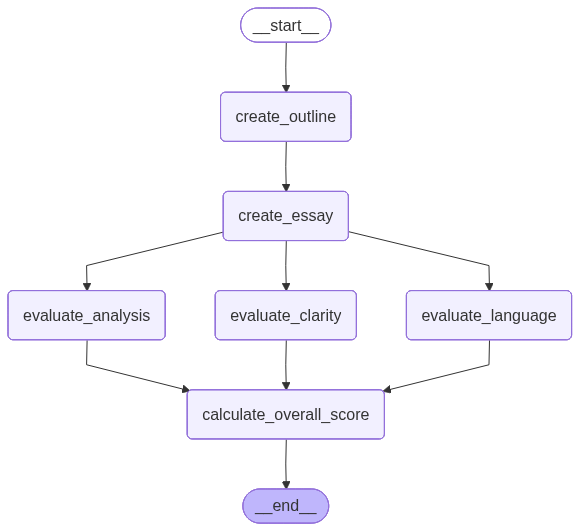

In [47]:
Image(workflow_.get_graph().draw_mermaid_png())

In [48]:
query = {"topic": "Ser Duncan the Tall in the tournament of the hand in the book 'The Hedge Knight'."}
output = workflow_.invoke(query)

In [53]:
print(output['essay'])

 Title: A Giant's Triumph: Ser Duncan the Tall and the Tournament of the Hand in George R.R. Martin's "The Hedge Knight"

In the intricate tapestry of Westeros, George R.R. Martin's "The Hedge Knight" weaves a tale of chivalry, honor, and personal growth, centered around the towering figure of Ser Duncan the Tall. This essay will delve into the narrative arc of this humble knight as he navigates the high-stakes Tournament of the Hand, ultimately emerging victorious and forever altering the political landscape of Westeros.

Ser Duncan the Tall, a bastard son of Lord Caswell, rose to prominence under the tutelage of Lord Ashford. His extraordinary height was matched by his unwavering sense of duty, making him not only an intimidating presence on the battlefield but also a gentleman of remarkable character off it. The Tournament of the Hand, a grand event held at King's Landing, served as a stage for Ser Duncan to prove himself in the face of the realm's most formidable knights.

Preparin

In [54]:
print(output['outline'])

 Title: A Giant's Triumph: Ser Duncan the Tall and the Tournament of the Hand in George R.R. Martin's "The Hedge Knight"

I. Introduction
   A. Brief overview of the story "The Hedge Knight" by George R.R. Martin
   B. Introducing the main character, Ser Duncan the Tall
      1. His background and origins
      2. His reputation as a knight and a gentleman
   C. Setting the stage for the Tournament of the Hand
      1. The significance of the tournament in Westeros' political landscape
      2. The expectations surrounding the event

II. Ser Duncan the Tall's Preparation for the Tournament
   A. His motivations for participating
      1. Desire to prove himself as a knight
      2. Duty towards his master, Lord Ashford
   B. Training regimen and strategies
      1. Physical preparation and training
      2. Tactical planning and alliances

III. The Tournament of the Hand
   A. Description of the tournament venue and atmosphere
   B. Ser Duncan's performances in the initial rounds
     